# Full hardware model — composite gate noise **+** readout, mitigated by ZNE/PEC **and** TREX

The realistic device has **two physically distinct error channels**:

1. **Gate noise** — the composite model of [Composite_noise_DZNE.ipynb](Composite_noise_DZNE.ipynb):
   ThermalRealistic ($T_1/T_2$ relaxation) $\circ$ MixedUnitary (biased-Pauli calibration residual).
   Mitigated by **ZNE / PEC**.
2. **Readout (measurement) error** — an IBM-like asymmetric bit-flip at measurement (assignment
   error $\sim$1–2 %). Mitigated by **TREX** (see [TREX_readout_mitigation.ipynb](TREX_readout_mitigation.ipynb)).

The point of this notebook is their **complementarity**. ZNE/PEC scale or invert *gate* channels;
they do **nothing** to readout (folding does not scale the measurement error, and PEC has no readout
representation). TREX corrects *readout* only. So on the full model:

| mitigation | removes gate noise | removes readout | lands at |
|---|:---:|:---:|---|
| none (noisy) | — | — | worst |
| ZNE / PEC only | ✓ | — | **readout floor** |
| TREX only | — | ✓ | **gate floor** |
| **TREX $\circ$ ZNE** | ✓ | ✓ | **$\approx 1$** |

Readout is added as a **separate add-on layer** (`SPEC_COMPOSITE_READOUT`); `SPEC_COMPOSITE` stays
gate-only so its DZNE-vs-PEC benchmark is unchanged. Validated in `smoke_composite_readout_trex.py`.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from mitiq import zne
from mitiq.zne.scaling import fold_global
from mitiq.zne.inference import ExpFactory, ExtrapolationError

import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *  # SPEC_COMPOSITE(_READOUT), READOUT_REALISTIC, trex_success_prob, trex_mitigated_executor, ...

warnings.filterwarnings("ignore")

SF = SPEC_COMPOSITE_READOUT.scale_factors  # [1, 1.5, 2, 3, 5]

def zne_exp(circuit, executor):
    """Non-adaptive ExpFactory ZNE (asymptote=None, 5 scale factors) -> NaN if the fit fails.

    The exponential ansatz matches the gate-noise decay toward the mixed fixed point and recovers
    ~1.0; with 5 scale factors it is robust (it converged 20/20 on the composite benchmark, where
    only the ADAPTIVE AdaExp failed on a few seeds). Poly2 is failure-proof but under-corrects over
    a short scale range, so we keep Exp and NaN-guard the rare non-convergence.
    """
    try:
        return zne.execute_with_zne(circuit, executor, scale_noise=fold_global,
                                    factory=ExpFactory(scale_factors=SF, asymptote=None))
    except ExtrapolationError:
        return float("nan")

print("qem loaded. Full-model spec:", SPEC_COMPOSITE_READOUT.name)

qem loaded. Full-model spec: CompositeReadout


## 2. The full hardware model

`SPEC_COMPOSITE_READOUT` = composite gate noise (per physical gate: `thermal_relaxation_error`
$\circ$ biased-Pauli) **plus** `READOUT_REALISTIC` attached via `add_readout_error` on every qubit.
The readout is asymmetric ($p_1 = P(0\,|\,1) > p_0 = P(1\,|\,0)$) because $T_1$ relaxation during the
$\sim$1–2 µs measurement dominates. We build three backends: **full** (gate+readout), **gate-only**
(reference for what TREX should recover), and **ideal**.

In [2]:
from qem.noise_models import T1_S, T2_S, GATE_TIME_S, EPS_MU_1Q, EPS_MU_2Q, ETA_MU

full_backend  = AerSimulator(noise_model=SPEC_COMPOSITE_READOUT.build_noise_model())
gate_backend  = AerSimulator(noise_model=SPEC_COMPOSITE.build_noise_model())      # gate noise only
ideal_backend = AerSimulator()

ro = READOUT_REALISTIC
print("GATE noise (composite): ThermalRealistic o MixedUnitary")
print(f"  T1={T1_S*1e6:.0f}us T2={T2_S*1e6:.0f}us  eps_1q={EPS_MU_1Q} eps_2q={EPS_MU_2Q} eta={ETA_MU}")
print(f"READOUT ({ro.name}): p0=P(1|0)={ro.p0}  p1=P(0|1)={ro.p1}")
print(f"  per-qubit assignment error ~ {[round(50*(a+b),2) for a,b in zip(ro.p0, ro.p1)]} %"
      f"   (asymmetric: p1 > p0 from T1 during readout)")
lam = {w: round(ro.lambda_support(w), 4) for w in [(0,), (1,), (0, 1)]}
print(f"  twirled eigenvalues lambda_w (TREX corrects each) = {lam}")

GATE noise (composite): ThermalRealistic o MixedUnitary
  T1=100us T2=80us  eps_1q=0.001 eps_2q=0.005 eta=4.0
READOUT (ReadoutRealistic): p0=P(1|0)=(0.01, 0.013)  p1=P(0|1)=(0.025, 0.03)
  per-qubit assignment error ~ [1.75, 2.15] %   (asymmetric: p1 > p0 from T1 during readout)
  twirled eigenvalues lambda_w (TREX corrects each) = {(0,): 0.965, (1,): 0.957, (0, 1): 0.9235}


## 3. Noisy baseline — the readout gap

Over 20 seeds, compare $P(\text{success})$ on the **full** model vs the **gate-only** model. The
gap between them is the readout contribution — the part ZNE/PEC cannot touch.

P(success)  full (gate+readout): mean=0.8261  bias=-0.1739
P(success)  gate-only          : mean=0.8541  bias=-0.1459
readout gap (gate_only - full) : +0.0280


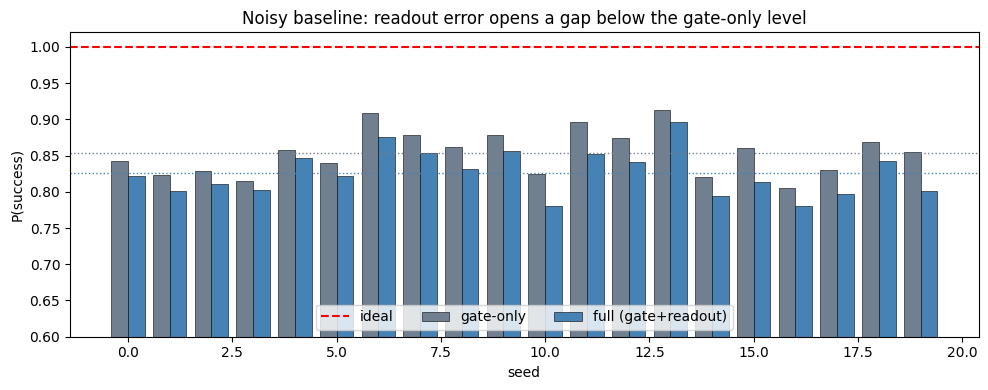

In [3]:
noisy_full = np.array([success_prob(full_backend, s) for s in SEEDS])
noisy_gate = np.array([success_prob(gate_backend, s) for s in SEEDS])
print(f"P(success)  full (gate+readout): mean={noisy_full.mean():.4f}  bias={noisy_full.mean()-IDEAL:+.4f}")
print(f"P(success)  gate-only          : mean={noisy_gate.mean():.4f}  bias={noisy_gate.mean()-IDEAL:+.4f}")
print(f"readout gap (gate_only - full) : {noisy_gate.mean()-noisy_full.mean():+.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(SEEDS))
ax.bar(x - 0.2, noisy_gate, 0.4, label="gate-only", color="slategray", edgecolor="black", linewidth=0.4)
ax.bar(x + 0.2, noisy_full, 0.4, label="full (gate+readout)", color="steelblue", edgecolor="black", linewidth=0.4)
ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label="ideal")
ax.axhline(noisy_gate.mean(), color="slategray", ls=":", lw=1)
ax.axhline(noisy_full.mean(), color="steelblue", ls=":", lw=1)
ax.set_xlabel("seed"); ax.set_ylabel("P(success)"); ax.set_ylim(0.6, 1.02)
ax.set_title("Noisy baseline: readout error opens a gap below the gate-only level")
ax.legend(ncol=3, loc="lower center"); plt.tight_layout(); plt.show()

## 4. ZNE & PEC leave a **readout floor**

`cached_benchmark(SPEC_COMPOSITE_READOUT)` runs the noisy baseline + four ZNE methods + PEC at
equal shot budget — with the composite **gate** representations, so **readout is left unmitigated**.
Side-by-side with the gate-only composite (from the DZNE-vs-PEC notebook), every mitigated method
drops from $\approx 1.0$ to a **readout floor** ($\approx 0.96$–$0.98$): confirmation that ZNE/PEC
do not address readout.

> First run computes PEC over 20 seeds (a few minutes) then caches to `qem_cache/`; re-runs reload
> in ms. `SPEC_COMPOSITE` is already cached from the composite notebook.

In [4]:
df_gate, _, _ = cached_benchmark(SPEC_COMPOSITE, seeds=SEEDS, verbose=False)          # gate only (cached)
df_full, raw_full, gammas_full = cached_benchmark(SPEC_COMPOSITE_READOUT, seeds=SEEDS) # gate + readout

methods = ["Noisy", "Richardson", "Poly2", "Exp", "AdaExp", "PEC"]
cmp = pd.DataFrame({
    "gate_only_mean":  [df_gate.loc[("Composite", m), "mean"] for m in methods],
    "full_mean":       [df_full.loc[("CompositeReadout", m), "mean"] for m in methods],
})
cmp.index = methods
cmp["readout_floor_gap"] = (cmp["gate_only_mean"] - cmp["full_mean"]).round(4)
print(cmp.to_string())
print("\n-> ZNE/PEC recover ~1.0 on gate-only, but stall ~0.96-0.98 with readout (the floor).")

[cache] loaded 'CompositeReadout' from CompositeReadout_2341a880100d.pkl (delete it or pass force=True to recompute)
            gate_only_mean  full_mean  readout_floor_gap
Noisy               0.8554     0.8267             0.0287
Richardson          0.6388     0.5815             0.0573
Poly2               0.9912     0.9618             0.0294
Exp                 1.0069     0.9706             0.0363
AdaExp              1.0015     0.9560             0.0455
PEC                 0.9947     0.9677             0.0270

-> ZNE/PEC recover ~1.0 on gate-only, but stall ~0.96-0.98 with readout (the floor).


## 5. TREX removes the readout floor

TREX mitigates the readout channel on $P(\text{target})$ (see the TREX notebook). Run on the **full**
backend it should strip the readout error and land back at the **gate-only** level (it does *not*
touch gate noise). Over 12 seeds:

noisy full  : 0.8296
TREX-only   : 0.8566   (removes readout)
gate-only   : 0.8546   <- TREX target (gate noise remains)
|TREX - gate_only| = 0.0021


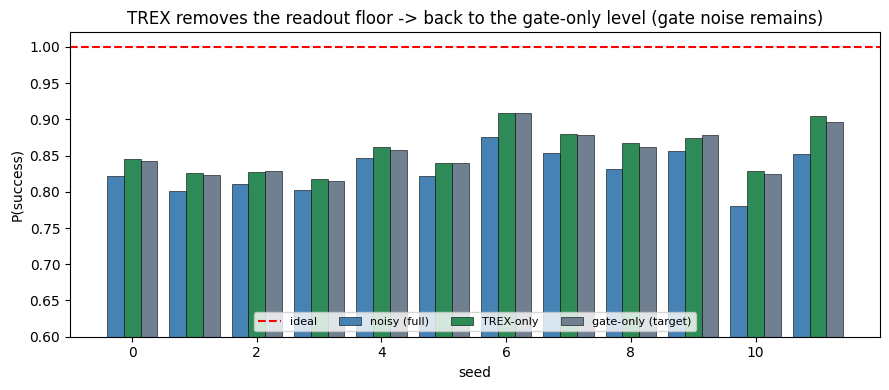

In [5]:
SEEDS_TREX = list(range(12))
NR = 16
SHOTS_T = 8000

trex_only = np.array([
    trex_success_prob(benchmark_circuit_cirq(s), mitiq_measurement_executor(full_backend, SHOTS_T),
                      target_key(s), num_randomizations=NR, random_state=s)
    for s in SEEDS_TREX
])
nf = noisy_full[SEEDS_TREX]; ng = noisy_gate[SEEDS_TREX]
print(f"noisy full  : {nf.mean():.4f}")
print(f"TREX-only   : {trex_only.mean():.4f}   (removes readout)")
print(f"gate-only   : {ng.mean():.4f}   <- TREX target (gate noise remains)")
print(f"|TREX - gate_only| = {abs(trex_only.mean()-ng.mean()):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(SEEDS_TREX))
ax.bar(x - 0.27, nf, 0.27, label="noisy (full)", color="steelblue", edgecolor="black", linewidth=0.4)
ax.bar(x, trex_only, 0.27, label="TREX-only", color="seagreen", edgecolor="black", linewidth=0.4)
ax.bar(x + 0.27, ng, 0.27, label="gate-only (target)", color="slategray", edgecolor="black", linewidth=0.4)
ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label="ideal")
ax.set_xlabel("seed"); ax.set_ylabel("P(success)"); ax.set_ylim(0.6, 1.02)
ax.set_title("TREX removes the readout floor -> back to the gate-only level (gate noise remains)")
ax.legend(ncol=4, loc="lower center", fontsize=8); plt.tight_layout(); plt.show()

## 6. Full stack: TREX $\circ$ ZNE recovers the ideal

Finally compose the two. `trex_mitigated_executor` returns a **readout-corrected** $P(\text{target})$;
feeding it into ZNE (`scale_noise=fold_global`) extrapolates away the **gate** noise on top — TREX
inside, ZNE outside. On the same seeds we show all four levels:

- **noisy** (gate+readout), **ZNE-only** (readout floor), **TREX-only** (gate floor),
  **TREX $\circ$ ZNE** ($\approx 1$).

> This is the costly cell: TREX runs at every ZNE scale factor, so we use a small seed set.

seed 0: noisy=0.8193  ZNE-only=0.9532  TREX-only=0.8489  TREXoZNE=0.9964
seed 1: noisy=0.7934  ZNE-only=0.9740  TREX-only=0.8285  TREXoZNE=1.0154
seed 2: noisy=0.8119  ZNE-only=0.9932  TREX-only=0.8283  TREXoZNE=1.0078
seed 3: noisy=0.8088  ZNE-only=0.9862  TREX-only=0.8217  TREXoZNE=1.0075
seed 4: noisy=0.8459  ZNE-only=0.9899  TREX-only=0.8599  TREXoZNE=1.0158
seed 5: noisy=0.8195  ZNE-only=0.9992  TREX-only=0.8365  TREXoZNE=1.0007

means: noisy=0.816  ZNE-only=0.983  TREX-only=0.837  TREX o ZNE=1.007


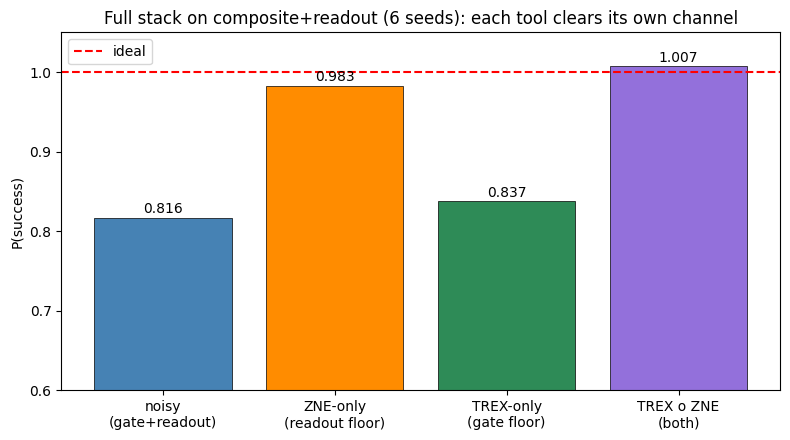

In [6]:
SEEDS_FULL = list(range(6))
rows = []
for s in SEEDS_FULL:
    circ = make_benchmark_circuit(s); tgt = target_key(s)
    noisy_v = success_prob(full_backend, s)
    zne_v   = zne_exp(circ, mitiq_executor(full_backend, s, SHOTS_T))                    # readout floor
    trex_v  = trex_success_prob(benchmark_circuit_cirq(s),
                                mitiq_measurement_executor(full_backend, SHOTS_T), tgt,
                                num_randomizations=NR, random_state=s)                    # gate floor
    tz_v    = zne_exp(circ, trex_mitigated_executor(full_backend, tgt, SHOTS_T,
                                                    num_randomizations=NR, random_state=s))  # both
    rows.append((noisy_v, zne_v, trex_v, tz_v))
    print(f"seed {s}: noisy={noisy_v:.4f}  ZNE-only={zne_v:.4f}  TREX-only={trex_v:.4f}  TREXoZNE={tz_v:.4f}")

arr = np.array(rows)
labels = ["noisy\n(gate+readout)", "ZNE-only\n(readout floor)", "TREX-only\n(gate floor)", "TREX o ZNE\n(both)"]
means = np.nanmean(arr, axis=0)
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]
print(f"\nmeans: " + "  ".join(f"{l.splitlines()[0]}={m:.3f}" for l, m in zip(labels, means)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(labels, means, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label="ideal")
for i, m in enumerate(means):
    ax.text(i, m + 0.006, f"{m:.3f}", ha="center", fontsize=10)
ax.set_ylabel("P(success)"); ax.set_ylim(0.6, 1.05)
ax.set_title(f"Full stack on composite+readout ({len(SEEDS_FULL)} seeds): each tool clears its own channel")
ax.legend(); plt.tight_layout(); plt.show()

### Summary

On the full hardware model (composite **gate** noise + realistic **readout**), the two mitigation
families are **orthogonal and complementary**:

- **ZNE / PEC alone** remove gate noise but stall at a **readout floor** ($\approx 0.96$–$0.98$)
  — §4 shows every mitigated method dropping from $\approx 1.0$ (gate-only) once readout is present.
- **TREX alone** removes readout and returns to the **gate-only** level (§5) — it does not touch
  gate noise.
- **TREX $\circ$ ZNE** — TREX as a readout-corrected executor inside ZNE — clears **both** channels
  and recovers $P(\text{success}) \approx 1$ (§6).

Practically: on real hardware you need a **readout** technique (TREX) *and* a **gate-noise**
technique (ZNE or PEC); neither substitutes for the other. The composition is exact in principle
because the two channels are addressed at different layers — TREX at the measurement, ZNE/PEC at the
gates. Cost note: TREX $\circ$ ZNE runs TREX at every scale factor, so it is the expensive combination
(few seeds here); the readout-floor evidence (§4) and TREX-only (§5) use the full 20/12 seeds.